In [1]:
import pandas as pd
import matplotlib.pyplot as plt

csv_path = "attack_success_rates.csv"
df = pd.read_csv(csv_path)

df

,dataset,eps,FGSM_targeted,FGSM_untargeted,PGD_targeted,PGD_untargeted,clean_accuracy
0,MNIST,0.050000,0.000000,0.046875,0.000000,0.062500,0.9885
1,MNIST,0.100000,0.007812,0.144531,0.019531,0.214844,0.9885
2,MNIST,0.200000,0.109375,0.574219,0.753906,0.980469,0.9885
3,MNIST,0.300000,0.437500,0.925781,1.000000,1.000000,0.9885
4,CIFAR-10,0.007843,0.171875,0.601562,0.222656,0.718750,0.7974
5,CIFAR-10,0.015686,0.343750,0.855469,0.714844,0.949219,0.7974
6,CIFAR-10,0.031373,0.460938,0.941406,0.976562,1.000000,0.7974
7,CIFAR-10,0.062745,0.507812,0.984375,1.000000,1.000000,0.7974


In [2]:
mnist_df = df[df["dataset"] == "MNIST"].copy()
cifar_df = df[df["dataset"] == "CIFAR-10"].copy()

print("MNIST")
display(mnist_df)

print("CIFAR-10")
display(cifar_df)

MNIST


,dataset,eps,FGSM_targeted,FGSM_untargeted,PGD_targeted,PGD_untargeted,clean_accuracy
0,MNIST,0.05,0.000000,0.046875,0.000000,0.062500,0.9885
1,MNIST,0.10,0.007812,0.144531,0.019531,0.214844,0.9885
2,MNIST,0.20,0.109375,0.574219,0.753906,0.980469,0.9885
3,MNIST,0.30,0.437500,0.925781,1.000000,1.000000,0.9885


CIFAR-10


,dataset,eps,FGSM_targeted,FGSM_untargeted,PGD_targeted,PGD_untargeted,clean_accuracy
4,CIFAR-10,0.007843,0.171875,0.601562,0.222656,0.718750,0.7974
5,CIFAR-10,0.015686,0.343750,0.855469,0.714844,0.949219,0.7974
6,CIFAR-10,0.031373,0.460938,0.941406,0.976562,1.000000,0.7974
7,CIFAR-10,0.062745,0.507812,0.984375,1.000000,1.000000,0.7974


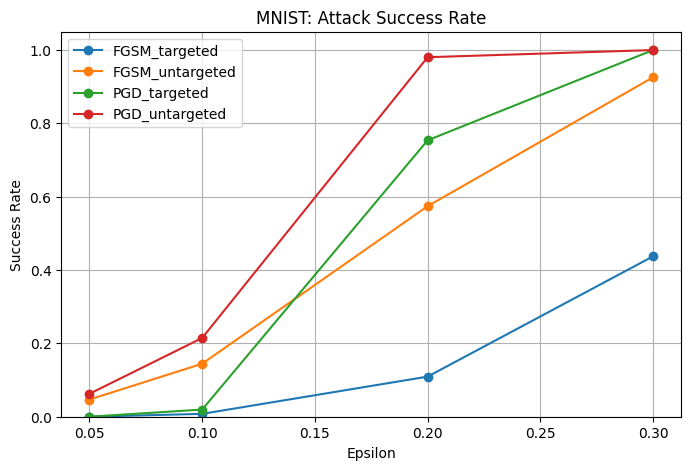

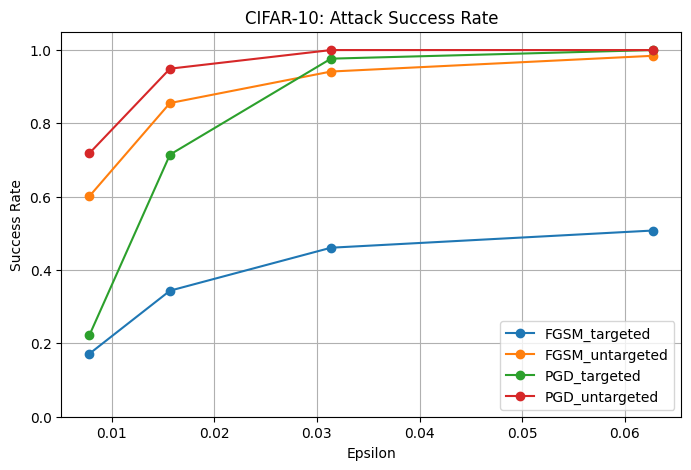

In [3]:
attack_columns = [
    "FGSM_targeted",
    "FGSM_untargeted",
    "PGD_targeted",
    "PGD_untargeted",
]

for dataset_name in df["dataset"].unique():
    sub_df = df[df["dataset"] == dataset_name].copy().sort_values("eps")

    plt.figure(figsize=(8, 5))
    for col in attack_columns:
        plt.plot(sub_df["eps"], sub_df[col], marker="o", label=col)

    plt.xlabel("Epsilon")
    plt.ylabel("Success Rate")
    plt.title(f"{dataset_name}: Attack Success Rate")
    plt.ylim(0, 1.05)
    plt.grid(True)
    plt.legend()
    plt.show()

In [ ]:
def fit(model, train_loader, test_loader, device, epochs=30, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

    history = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": [],
    }

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        test_loss, test_acc = evaluate(model, test_loader, criterion, device)

        scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        print(
            f"[Epoch {epoch:02d}] "
            f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
            f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}"
        )

    return history